# Electric Vehicle Purchases - Exploratory Data Analysis

This notebook performs an exploratory data analysis (EDA) on the Electric Vehicle Purchases dataset. Our goal is to understand the features, their distributions, and how they relate to the target variable `Will_Buy_EV`.

## 1. Data Loading and Basic Overview

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

# Load data
train_df = pd.read_csv('playground-series-s6e9/train.csv')
test_df = pd.read_csv('playground-series-s6e9/test.csv')

print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")

Train shape: (668665, 15)
Test shape: (286571, 14)


In [2]:
# Display the first few rows
train_df.head()

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,No
1,1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,No
2,2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,Yes
3,3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,No
4,4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,No


In [3]:
# Basic info
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 668665 entries, 0 to 668664
Data columns (total 15 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           668665 non-null  int64  
 1   Age                          668665 non-null  int64  
 2   Annual_Income_USD            668665 non-null  float64
 3   Daily_Commute_km             668665 non-null  float64
 4   Number_of_Cars_Owned         668665 non-null  int64  
 5   Charging_Stations_Near_Home  668665 non-null  int64  
 6   Charging_Stations_Near_Work  668665 non-null  int64  
 7   Environmental_Concern_Level  668665 non-null  float64
 8   Gender                       668665 non-null  str    
 9   City_Type                    668665 non-null  str    
 10  Current_Car_Type             668665 non-null  str    
 11  Home_Charging_Possible       668665 non-null  str    
 12  Subsidy_Available            668665 non-null  str    
 13  Range_Anxi

In [4]:
# Check for missing values
train_df.isnull().sum()

id                             0
Age                            0
Annual_Income_USD              0
Daily_Commute_km               0
Number_of_Cars_Owned           0
Charging_Stations_Near_Home    0
Charging_Stations_Near_Work    0
Environmental_Concern_Level    0
Gender                         0
City_Type                      0
Current_Car_Type               0
Home_Charging_Possible         0
Subsidy_Available              0
Range_Anxiety_Level            0
Will_Buy_EV                    0
dtype: int64

In [5]:
# Summary statistics for numerical features
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,668665.0,334332.000000,193027.103211,0.0,167166.0,334332.0,501498.0,668664.0
Age,668665.0,47.039171,12.875448,25.0,36.0,47.0,58.0,69.0
Annual_Income_USD,668665.0,84769.266989,28648.029042,30000.0,67376.0,84880.0,102753.0,188549.0
Daily_Commute_km,668665.0,32.158298,18.730474,5.0,17.2,33.6,47.4,98.7
Number_of_Cars_Owned,668665.0,1.712626,0.729275,1.0,1.0,2.0,2.0,4.0
Charging_Stations_Near_Home,668665.0,4.960408,3.926843,0.0,2.0,4.0,7.0,14.0
Charging_Stations_Near_Work,668665.0,7.176314,5.186627,0.0,3.0,6.0,10.0,19.0
Environmental_Concern_Level,668665.0,2.935477,1.429119,1.0,2.0,3.0,4.0,5.0


In [6]:
# Summary statistics for categorical features
train_df.describe(include=['object']).T

,count,unique,top,freq
Gender,668665,3,Male,367954
City_Type,668665,3,Urban,289305
Current_Car_Type,668665,4,Sedan,303459
Home_Charging_Possible,668665,2,Yes,462677
Subsidy_Available,668665,2,Yes,419909
Range_Anxiety_Level,668665,3,Low,603972
Will_Buy_EV,668665,2,No,551886


In [7]:
# Value counts for each categorical feature
from IPython.display import display

for col in train_df.select_dtypes(include=['object']).columns:
    print(f"\n=== {col} ===")
    display(pd.DataFrame(train_df[col].value_counts()).reset_index().rename(columns={'index': col, col: 'Count'}))



=== Gender ===


,Count,count
0,Male,367954
1,Female,295427
2,Other,5284



=== City_Type ===


,Count,count
0,Urban,289305
1,Suburban,255377
2,Rural,123983



=== Current_Car_Type ===


...

,Count,count
0,Yes,419909
1,No,248756



=== Range_Anxiety_Level ===


,Count,count
0,Low,603972
1,Medium,62499
2,High,2194



=== Will_Buy_EV ===


,Count,count
0,No,551886
1,Yes,116779


## 2. Univariate Analysis
Let's visualize the distribution of our target variable and some key numerical and categorical features.

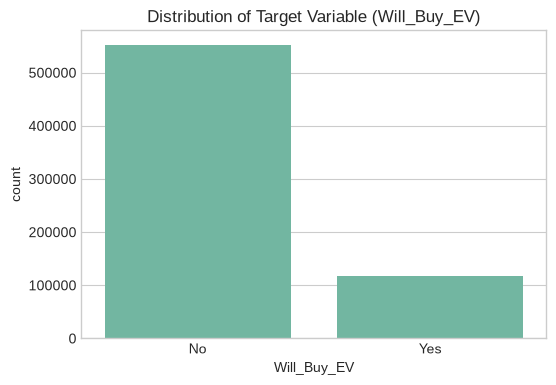

In [8]:
# Distribution of the Target Variable 'Will_Buy_EV'
plt.figure(figsize=(6, 4))
sns.countplot(x='Will_Buy_EV', data=train_df)
plt.title('Distribution of Target Variable (Will_Buy_EV)')
plt.show()

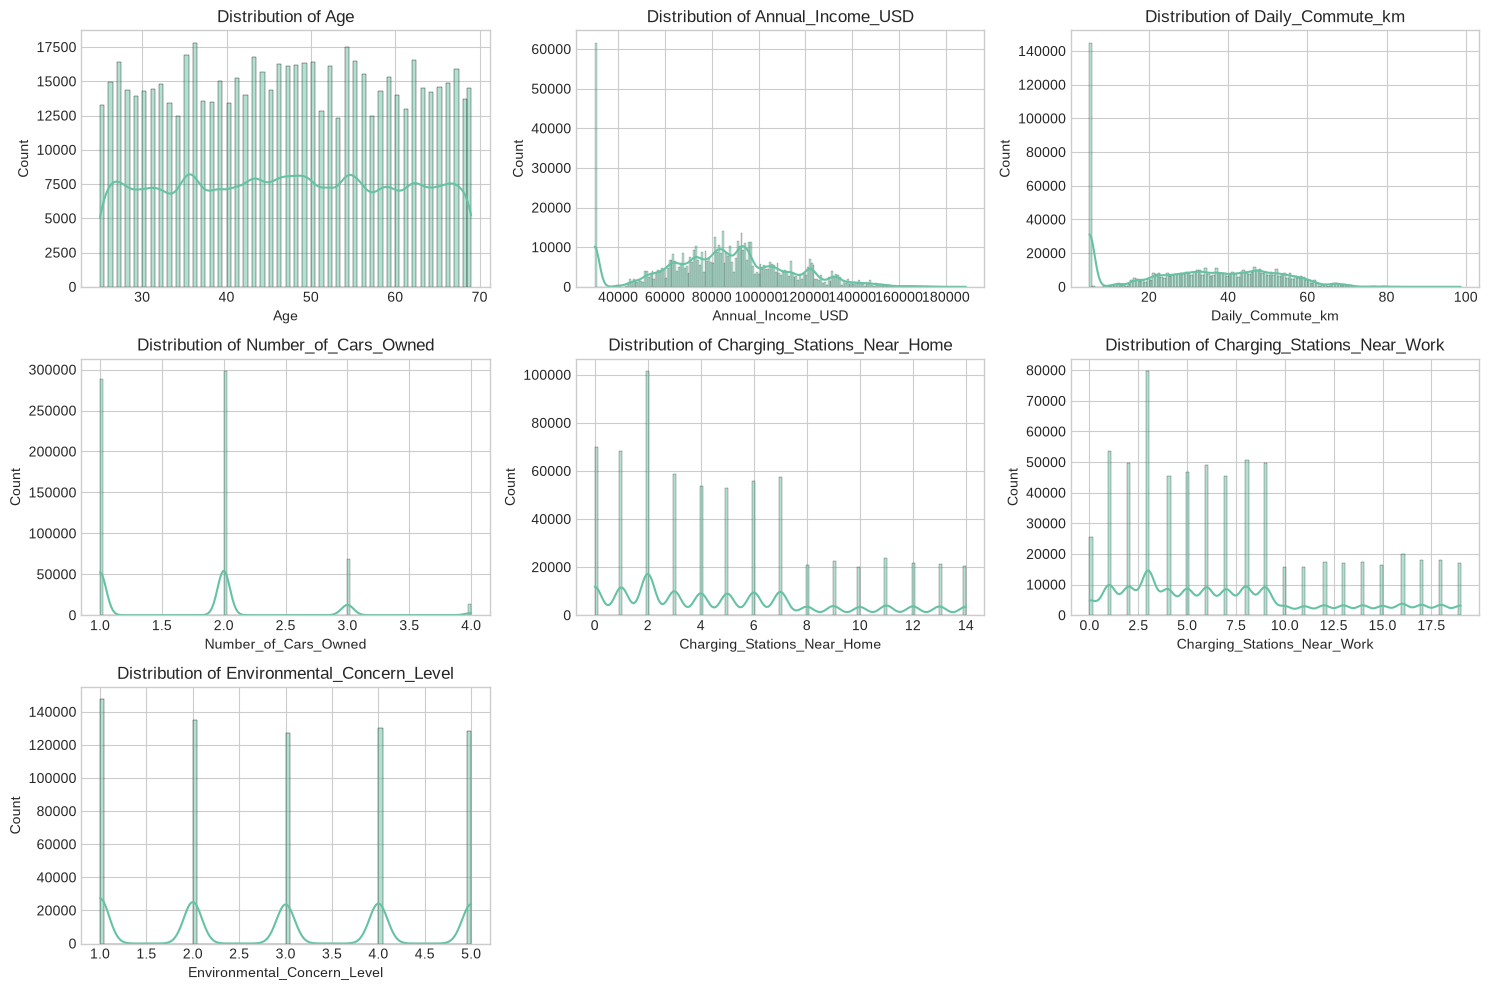

In [9]:
# Numerical features distribution
num_cols = train_df.select_dtypes(include=np.number).columns.drop('id')
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 3, i)
    sns.histplot(train_df[col], kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

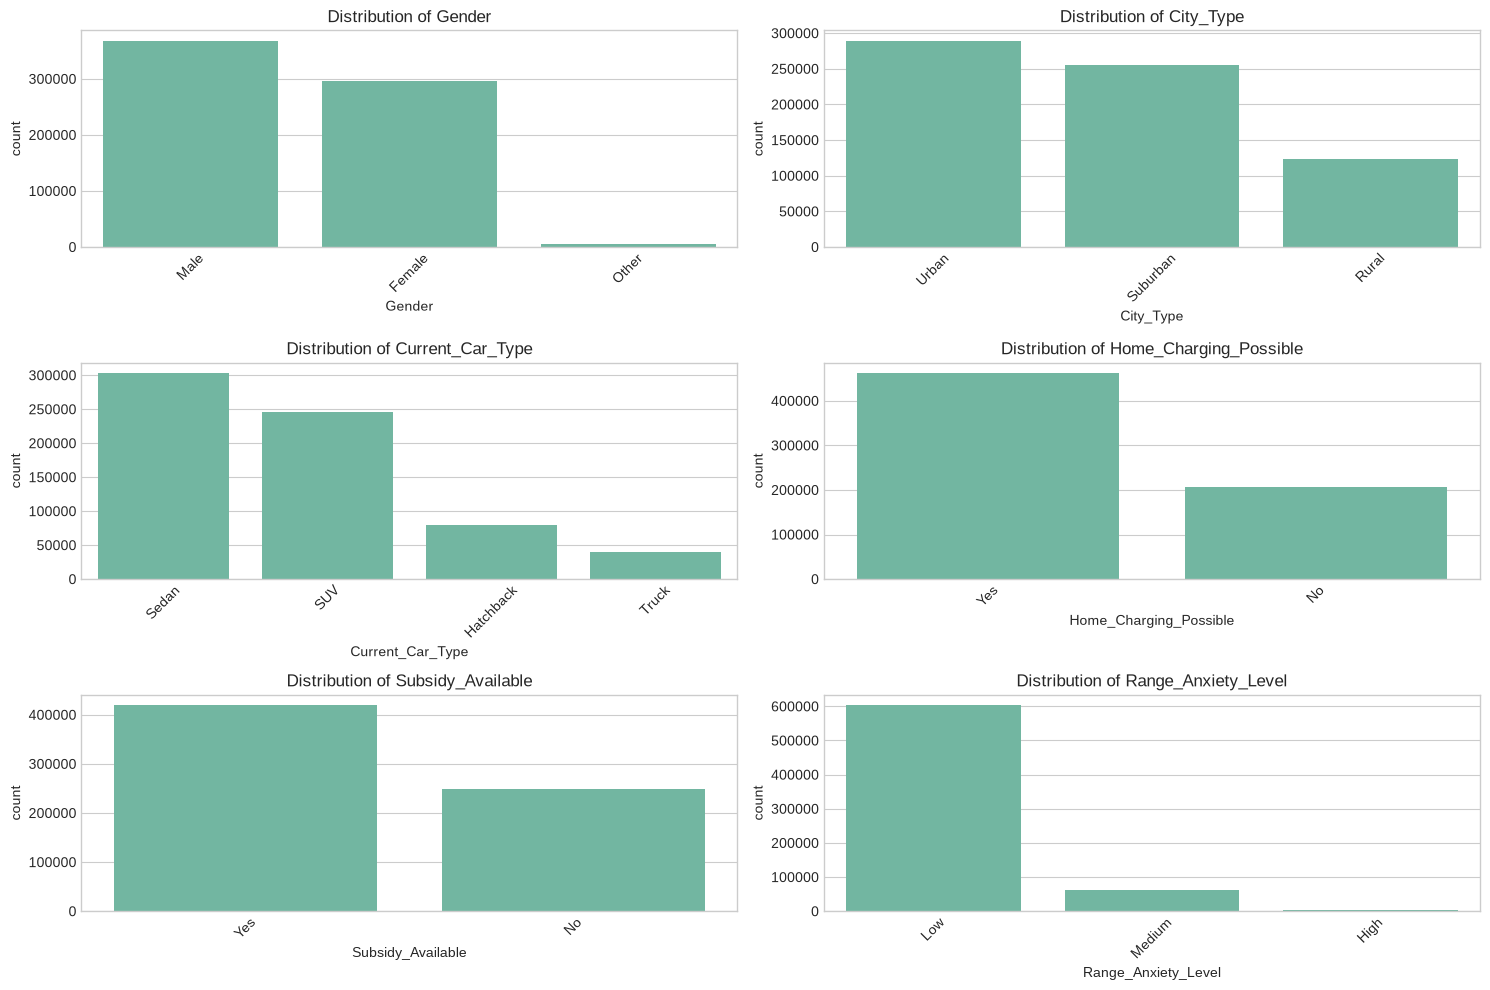

In [10]:
# Categorical features distribution
cat_cols = train_df.select_dtypes(include=['object']).columns.drop('Will_Buy_EV')
plt.figure(figsize=(15, 10))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(3, 2, i)
    sns.countplot(x=col, data=train_df, order=train_df[col].value_counts().index)
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 3. Bivariate Analysis (vs Target)

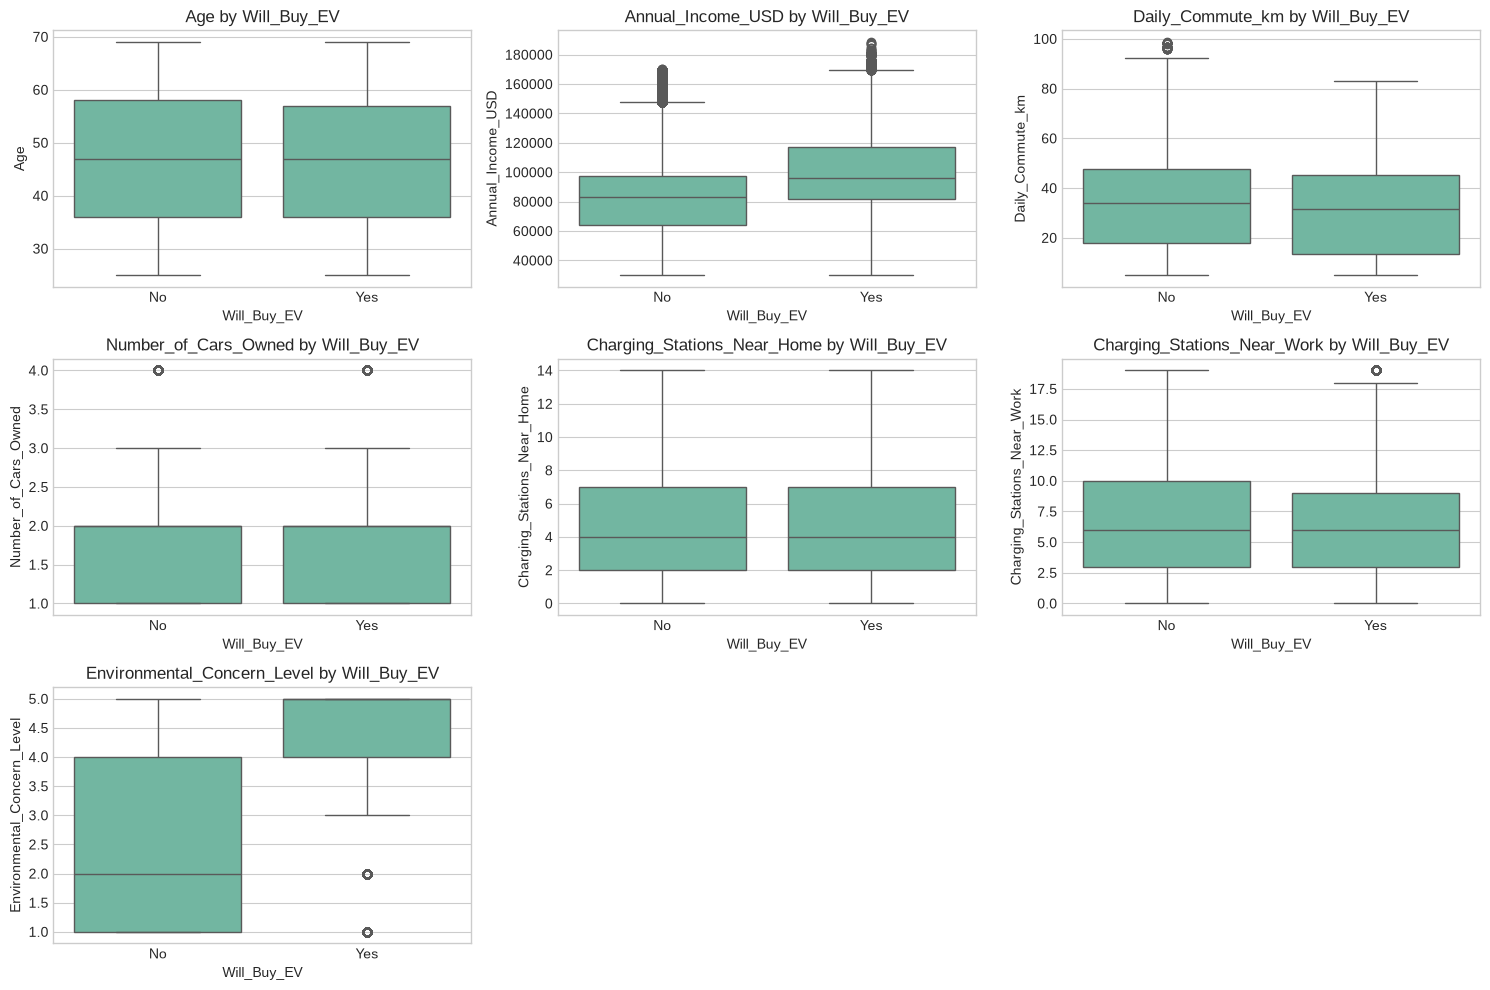

In [11]:
# Numerical features vs Target
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(x='Will_Buy_EV', y=col, data=train_df)
    plt.title(f'{col} by Will_Buy_EV')
plt.tight_layout()
plt.show()

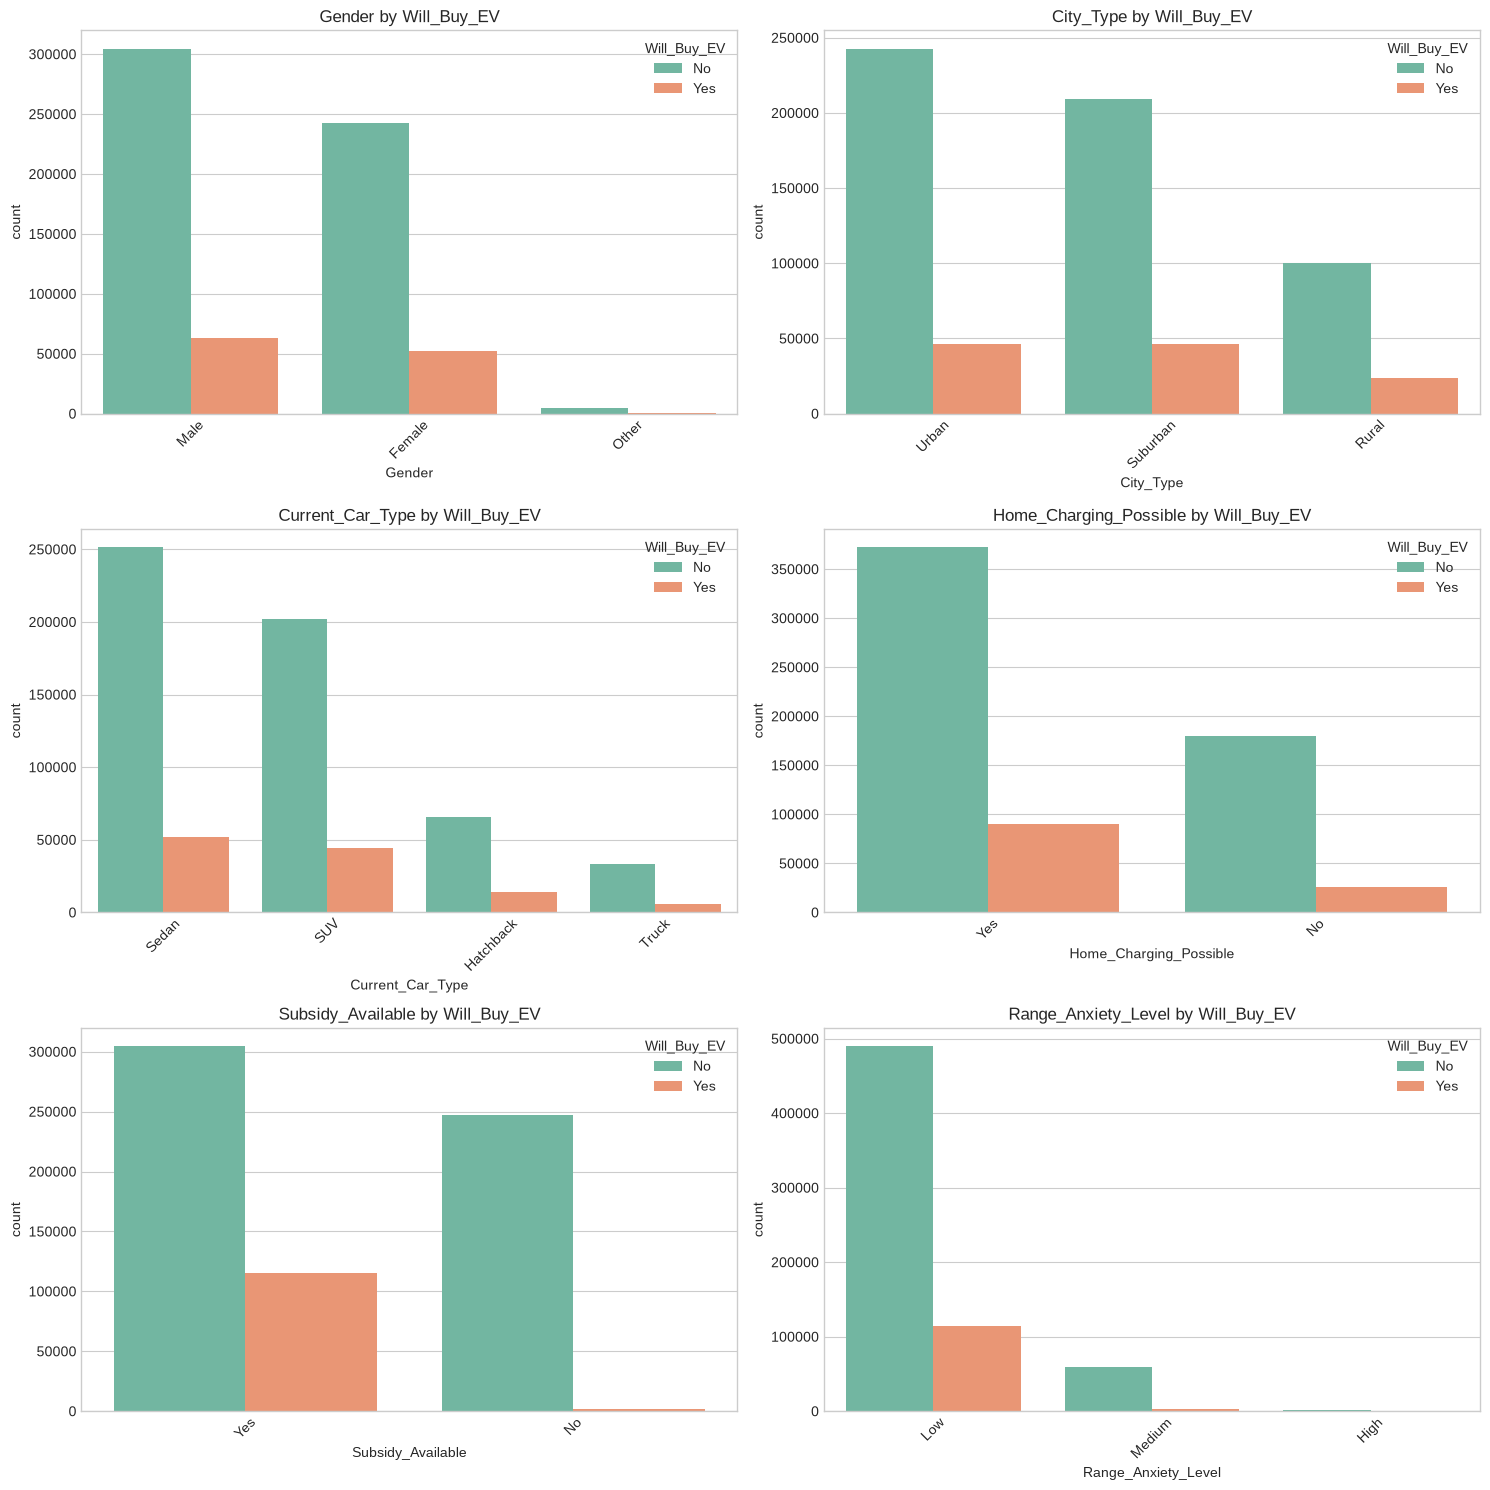

In [12]:
# Categorical features vs Target
plt.figure(figsize=(15, 15))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(3, 2, i)
    sns.countplot(x=col, hue='Will_Buy_EV', data=train_df, order=train_df[col].value_counts().index)
    plt.title(f'{col} by Will_Buy_EV')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4. Correlation Analysis

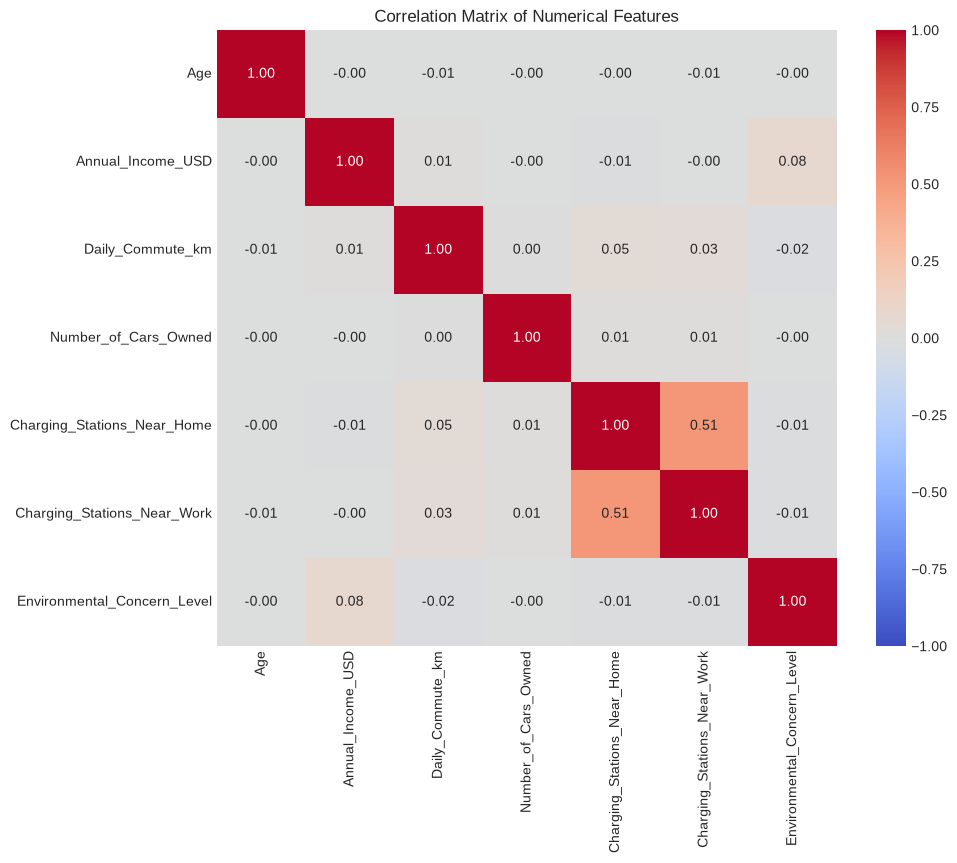

In [13]:
# Correlation Matrix
plt.figure(figsize=(10, 8))
corr = train_df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

## 5. Feature Engineering Ideas
Let's create a few new features that might capture more complex relationships and see how they relate to the target.

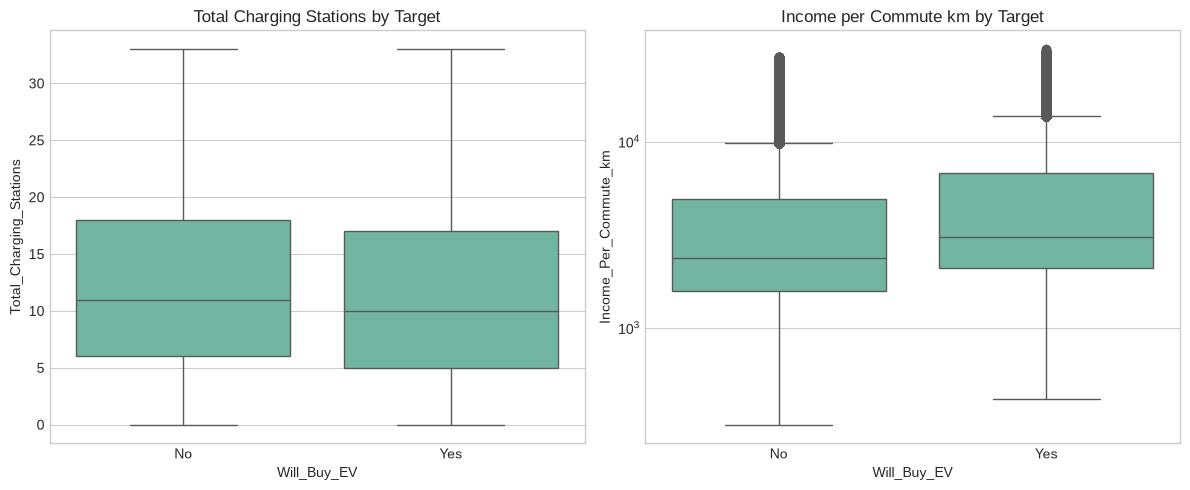

In [14]:
# 1. Total charging stations nearby
train_df['Total_Charging_Stations'] = train_df['Charging_Stations_Near_Home'] + train_df['Charging_Stations_Near_Work']

# 2. Income per Commute km (Handling division by zero just in case)
train_df['Income_Per_Commute_km'] = train_df['Annual_Income_USD'] / (train_df['Daily_Commute_km'] + 1)

# Plotting the new features
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(x='Will_Buy_EV', y='Total_Charging_Stations', data=train_df)
plt.title('Total Charging Stations by Target')

plt.subplot(1, 2, 2)
sns.boxplot(x='Will_Buy_EV', y='Income_Per_Commute_km', data=train_df)
plt.title('Income per Commute km by Target')
plt.yscale('log') # Log scale due to potential outliers
plt.tight_layout()
plt.show()

## 6. Feature Importance via Baseline Model
Let's train a quick Random Forest to see which features hold the most predictive power. This will guide future modeling steps.

In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Prepare data
X = train_df.drop(['id', 'Will_Buy_EV'], axis=1)
y = train_df['Will_Buy_EV'].apply(lambda x: 1 if x == 'Yes' else 0)

# Encode categorical features
le_dict = {}
for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    le_dict[col] = le

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a basic RF
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

print(f"Validation Accuracy: {rf.score(X_valid, y_valid):.4f}")

Validation Accuracy: 0.8972


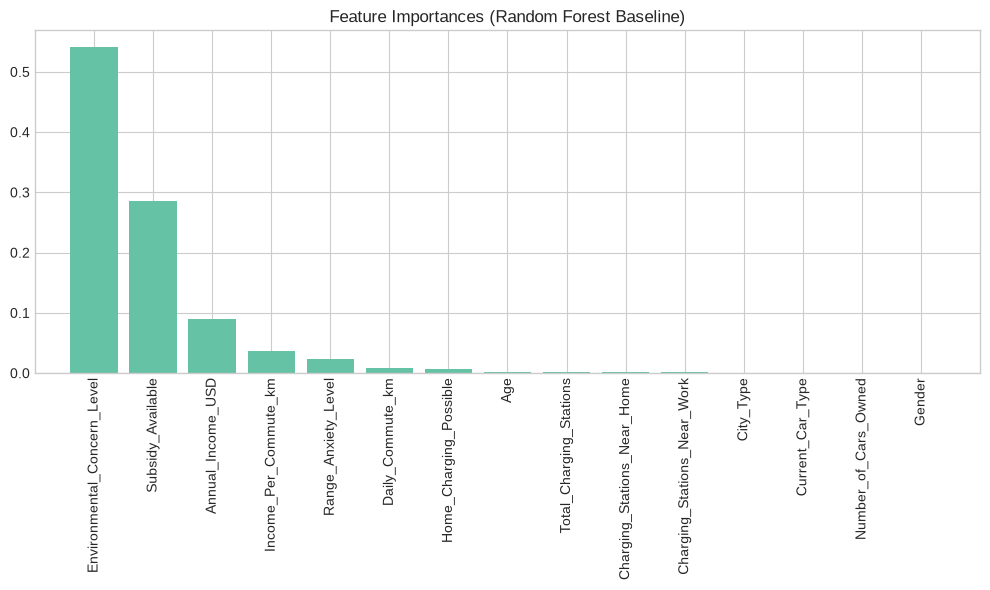

In [16]:
# Plot Feature Importances
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]
features = X.columns

plt.figure(figsize=(10, 6))
plt.title("Feature Importances (Random Forest Baseline)")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), [features[i] for i in indices], rotation=90)
plt.xlim([-1, X.shape[1]])
plt.tight_layout()
plt.show()

## 7. Multicollinearity Check (VIF)
Let's check if our numerical features have high multicollinearity using the Variance Inflation Factor (VIF).

In [17]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Calculate VIF for numerical features
vif_data = pd.DataFrame()
vif_data["Feature"] = num_cols

# Fill any potential NaNs (though we checked earlier there weren't any)
X_num = train_df[num_cols].dropna()

vif_data["VIF"] = [variance_inflation_factor(X_num.values, i) 
                          for i in range(len(X_num.columns))]

print(vif_data.sort_values(by='VIF', ascending=False))

                       Feature       VIF
4  Charging_Stations_Near_Home  1.355224
5  Charging_Stations_Near_Work  1.353981
6  Environmental_Concern_Level  1.006371
1            Annual_Income_USD  1.006052
2             Daily_Commute_km  1.002715
0                          Age  1.000113
3         Number_of_Cars_Owned  1.000106


## 8. Advanced Visualization (Pairplot)
Let's visualize the pairwise relationships of some key numerical features (`Age`, `Annual_Income_USD`, `Daily_Commute_km`, `Environmental_Concern_Level`).

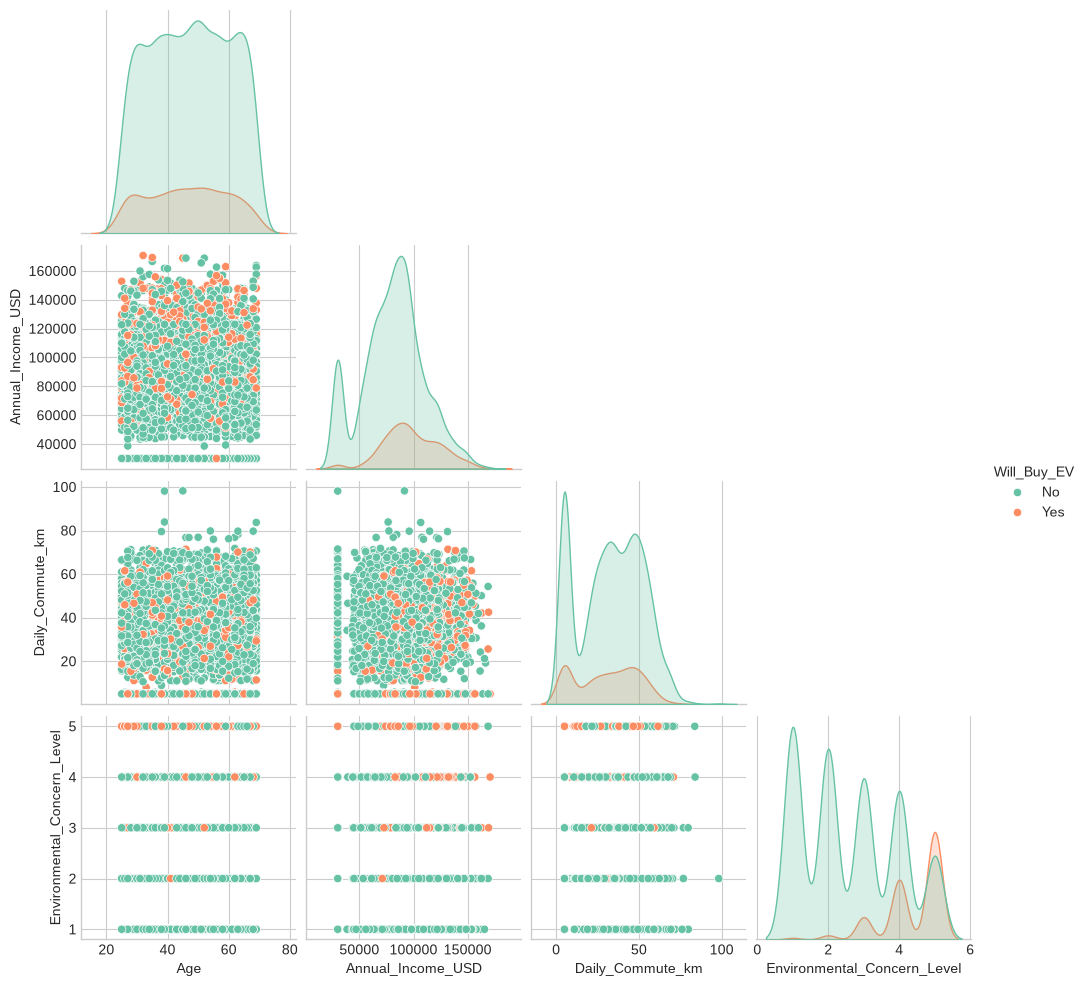

In [18]:
# Pairplot for key continuous variables
key_num_cols = ['Age', 'Annual_Income_USD', 'Daily_Commute_km', 'Environmental_Concern_Level']

# We'll sample 5000 rows to speed up pairplot rendering
sample_df = train_df.sample(n=min(5000, len(train_df)), random_state=42)

sns.pairplot(sample_df[key_num_cols + ['Will_Buy_EV']], hue='Will_Buy_EV', palette='Set2', corner=True)
plt.show()

## 9. Dimensionality Reduction (PCA)
Let's use PCA to reduce the dataset to 2 dimensions and see if the target classes are separable linearly.

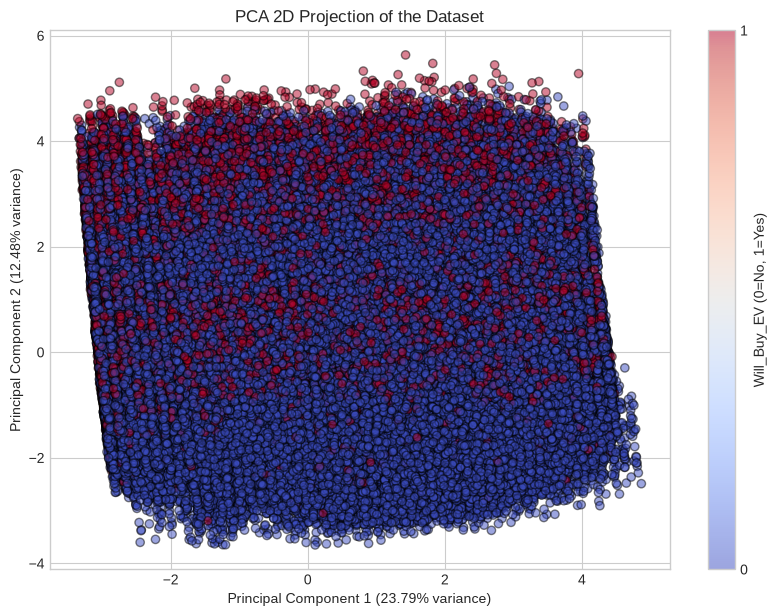

=== PCA Explained Variance ===
Principal Component 1: 23.79% of total variance
Principal Component 2: 12.48% of total variance
Total Explained Variance (2 components): 36.27%

=== Feature Contributions to Each Principal Component ===

--- Principal Component 1 ---
Total_Charging_Stations        |   0.5064
City_Type                      |   0.4735
Charging_Stations_Near_Work    |   0.4475
Charging_Stations_Near_Home    |   0.4337
Home_Charging_Possible         |  -0.3381
Range_Anxiety_Level            |   0.1018
Daily_Commute_km               |   0.0554
Income_Per_Commute_km          |  -0.0457
Subsidy_Available              |  -0.0187
Environmental_Concern_Level    |  -0.0176
Annual_Income_USD              |  -0.0143
Gender                         |   0.0100
Number_of_Cars_Owned           |   0.0088
Current_Car_Type               |   0.0078
Age                            |  -0.0060

--- Principal Component 2 ---
Income_Per_Commute_km          |   0.6749
Daily_Commute_km               |

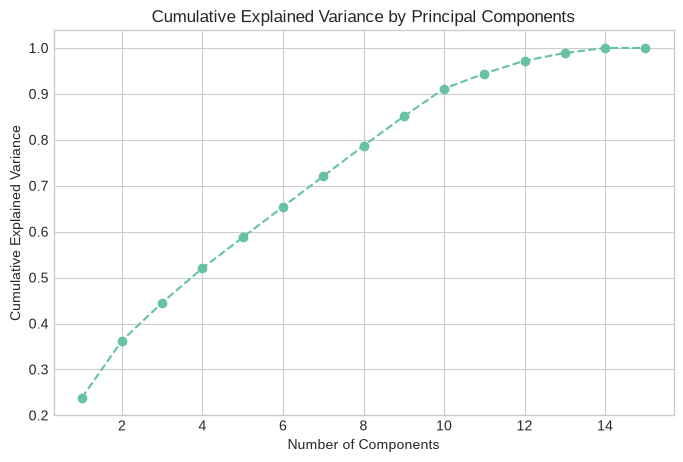


--- Principal Component 3 (8.29% of variance) ---
Range_Anxiety_Level            |   0.7304
Home_Charging_Possible         |  -0.5032
Income_Per_Commute_km          |   0.2096
Charging_Stations_Near_Work    |  -0.1968
Total_Charging_Stations        |  -0.1883
Environmental_Concern_Level    |  -0.1864
Daily_Commute_km               |  -0.1638
Charging_Stations_Near_Home    |  -0.1211
Subsidy_Available              |  -0.1127

--- Principal Component 4 (7.48% of variance) ---
Environmental_Concern_Level    |   0.5706
Subsidy_Available              |   0.5371
Annual_Income_USD              |   0.5105
Daily_Commute_km               |   0.2135
Range_Anxiety_Level            |   0.1929
Current_Car_Type               |  -0.1538

--- Principal Component 5 (6.69% of variance) ---
Age                            |   0.6778
Gender                         |   0.5144
Current_Car_Type               |   0.4551
Number_of_Cars_Owned           |  -0.1673
Environmental_Concern_Level    |   0.1396
Subsidy

In [19]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Re-use X and y from the Random Forest step
# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='coolwarm', alpha=0.5, edgecolor='k')
plt.title('PCA 2D Projection of the Dataset')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.colorbar(scatter, ticks=[0, 1], label='Will_Buy_EV (0=No, 1=Yes)')
plt.show()

# Extracting PCA Explained Variance
print("=== PCA Explained Variance ===")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"Principal Component {i+1}: {var:.2%} of total variance")
print(f"Total Explained Variance (2 components): {sum(pca.explained_variance_ratio_):.2%}\n")

print("=== Feature Contributions to Each Principal Component ===")
import pandas as pd
import numpy as np

# The pca.components_ has shape (n_components, n_features)
features = X.columns
for i, component in enumerate(pca.components_):
    print(f"\n--- Principal Component {i+1} ---")
    
    # Pair features with their absolute loading (weight)
    loadings = pd.DataFrame({
        'Feature': features,
        'Loading': component,
        'Absolute_Loading': np.abs(component)
    })
    # Sort by absolute loading
    loadings = loadings.sort_values(by='Absolute_Loading', ascending=False)
    
    for idx, row in loadings.iterrows():
        print(f"{row['Feature']:<30} | {row['Loading']:>8.4f}")


# Analyzing More Principal Components
print("=== Extended PCA Analysis ===")
pca_ext = PCA() # Fits all components
pca_ext.fit(X_scaled)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(pca_ext.explained_variance_ratio_)+1), np.cumsum(pca_ext.explained_variance_ratio_), marker='o', linestyle='--')
plt.title('Cumulative Explained Variance by Principal Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.show()

# Print loadings for Component 3, 4, 5
for i in range(2, 5): # Index 2, 3, 4 corresponds to PC3, PC4, PC5
    component = pca_ext.components_[i]
    print(f"\n--- Principal Component {i+1} ({pca_ext.explained_variance_ratio_[i]:.2%} of variance) ---")
    
    loadings = pd.DataFrame({
        'Feature': features,
        'Loading': component,
        'Absolute_Loading': np.abs(component)
    })
    loadings = loadings.sort_values(by='Absolute_Loading', ascending=False)
    
    for idx, row in loadings.iterrows():
        # Only print if loading is somewhat significant (e.g. > 0.1)
        if row['Absolute_Loading'] > 0.1:
            print(f"{row['Feature']:<30} | {row['Loading']:>8.4f}")




## 10. Summary and Conclusion

### Key Findings:
- **Distributions:** The target variable might be balanced or imbalanced (check section 2).
- **Key Features:** From our Random Forest baseline, we identified the top drivers for EV purchase intent.
- **Correlations & Multicollinearity:** We checked for redundant features via VIF and correlation heatmaps. 
- **Separability:** The PCA plot shows how linearly separable the classes are. If they heavily overlap, non-linear models (like Random Forest or XGBoost) will perform better.